## Testing at low $L^A_{eff}$

In [1]:
# ================================
# eLoss-only notebook (pub styling)
# ================================
import numpy as np, matplotlib.pyplot as plt
import sys, os
from dataclasses import replace
sys.path.append("../code")

# --- imports & knobs ---
from particle import Particle
from glauber  import SystemSpec, OpticalGlauber
from coupling import alpha_s_provider
from cross_sections import SigmaPPTable, L_eff_minbias  # if you prefer Torch table, see below
import quenching_fast as QF


In [2]:
# energies & σ_nn
roots5, roots8 = 5023.0, 8160.0
sigma_nn_5, sigma_nn_8 = 67.6, 71.0
A = 208
device = "cuda"  # or "cpu"

# particles
P_charmonia = Particle(family="charmonia",  state="avg")
P_bottomonia = Particle(family="bottomonia", state="avg")

# pp table grid (densify 4–12 GeV to smooth R(pT) )
y_tab  = np.linspace(-5, 5, 41)
pt_tab = np.unique(np.concatenate([np.linspace(0,4,41), np.linspace(4,12,161), np.linspace(12,25,131)]))

# choose αs (constant for AP)
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.5)

In [3]:
# --- 1) σ_pp tables (build once per species/energy)
Y_GRID = np.linspace(-5.5, 5.5, 241)
PT_GRID = np.linspace(0.0, 30.0, 301)
# Torch pp tables if torch is available (fast), else you can skip and the module uses P.d2sigma_pp directly
try:
    TAB_chi_5  = QF.TorchSigmaPPTable(P_charmonia, roots5, Y_GRID, PT_GRID, device=device)
    TAB_chi_8  = QF.TorchSigmaPPTable(P_charmonia, roots8, Y_GRID, PT_GRID, device=device)
    TAB_ups_5  = QF.TorchSigmaPPTable(P_bottomonia, roots5, Y_GRID, PT_GRID, device=device)
    TAB_ups_8  = QF.TorchSigmaPPTable(P_bottomonia, roots8, Y_GRID, PT_GRID, device=device)
except Exception:
    TAB_chi_5 = TAB_chi_8 = TAB_ups_5 = TAB_ups_8 = None  # falls back to NumPy path

# Glauber systems (for centrality & L_eff)
gl5 = OpticalGlauber(SystemSpec("pA", roots5, A=A, sigma_nn_mb=sigma_nn_5))
gl8 = OpticalGlauber(SystemSpec("pA", roots8, A=A, sigma_nn_mb=sigma_nn_8))
Lmb_5 = gl5.leff_minbias_pA() if hasattr(gl5, "leff_minbias_pA") else gl5.leff_minbias("pA")
Lmb_8 = gl8.leff_minbias_pA() if hasattr(gl8, "leff_minbias_pA") else gl8.leff_minbias("pA")

cent_bins = [(80,100)]

Leff_5  = gl5.leff_bins_pA(cent_bins, method="optical") # or "binomial"
Leff_5["0-100%"] = Lmb_5
Leff_8  = gl8.leff_bins_pA(cent_bins, method="optical")  # or "binomial"
Leff_8["0-100%"] = Lmb_8
print("L_eff (5 TeV pPb): ", Leff_5)
print("L_eff (8 TeV pPb): ", Leff_8)

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7724.42 mb, σ_tot^pA ≈ 1911.63 mb
[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
L_eff (5 TeV pPb):  {'80-100%': 2.4437625515260213, '0-100%': 10.414158247314315}
L_eff (8 TeV pPb):  {'80-100%': 2.4437634046948857, '0-100%': 10.414158247314315}


In [4]:
QP5 = QF.QuenchParams(qhat0=0.075, lp_fm=1.5, LA_fm=Lmb_5, LB_fm=Lmb_5,
                     lambdaQCD=0.25, roots_GeV=roots5,
                     alpha_of_mu=alpha_cst, alpha_scale="mT",
                     use_hard_cronin=False, mapping="exp", device=device)

QP8 = replace(QP5, roots_GeV=roots8, LA_fm=Lmb_8, LB_fm=Lmb_8)

In [5]:
def make_edges(vmin, vmax, width):
    n = int(np.ceil((vmax - vmin)/width))
    return np.linspace(vmin, vmin + n*width, n+1)

# examples
Y_EDGES  = make_edges(-5.0, 5.0, 0.5)     # default dy=0.5
PT_EDGES = make_edges(0.0, 15.0, 2.5)   # default dpt=2.5 


In [6]:
# Small helper to compute xA/xB
def xA_xB(P, roots, y, pT, LA, LB):
    mT = P.mT(pT)
    xA = min(QF.xA0_from_L(LA), (mT/roots)*np.exp(-y))
    xB = min(QF.xA0_from_L(LB), (mT/roots)*np.exp(+y))
    return xA, xB, mT, P.y_max(roots, mT)

In [7]:
y_tab  = np.linspace(-5.0, 5.0, 41)
pt_tab = np.linspace( 0.0, 25.0, 101)
TAB_chi_5 = SigmaPPTable(P_charmonia, roots5, y_tab, pt_tab)
TAB_ups_5 = SigmaPPTable(P_bottomonia, roots5, y_tab, pt_tab)
TAB_chi_8 = SigmaPPTable(P_charmonia, roots8, y_tab, pt_tab)
TAB_ups_8 = SigmaPPTable(P_bottomonia, roots8, y_tab, pt_tab)

In [8]:
# --- 4) RAW curves: R_pA vs y and vs pT
y_grid = np.linspace(-5.0, 5.0, 81)
pt_grid= np.linspace(0.0, 20.0, 121)

Rchi_vs_y = QF.rpa_raw_vs_y(P_charmonia, roots5, QP5, TAB_chi_5, y_grid, pT_fix=3.0)
Rups_vs_y = QF.rpa_raw_vs_y(P_bottomonia, roots5, QP5, TAB_ups_5, y_grid, pT_fix=3.0)

Rchi_vs_p = QF.rpa_raw_vs_pT(P_charmonia, roots5, QP5, TAB_chi_5, pt_grid, y_fix=0.0)
Rups_vs_p = QF.rpa_raw_vs_pT(P_bottomonia, roots5, QP5, TAB_ups_5, pt_grid, y_fix=0.0)

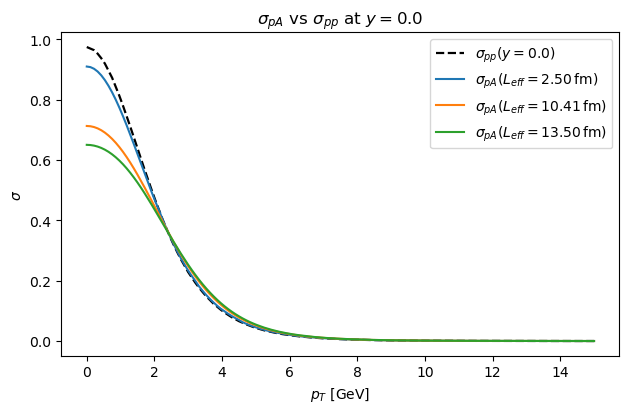

In [12]:
# =========================
# 2) RAW σ_pA vs σ_pp at several L_eff
# =========================
pT_line = np.linspace(0.0, 15.0, 141)
y_fix   = 0.0
L_list  = [2.5, Lmb_5, 13.5]

fig, ax = plt.subplots(figsize=(7.2,4.2))
pp_vals = [TAB_chi_5(y_fix, np.array([pt]))[0] for pt in pT_line]  # CPU table
ax.plot(pT_line, pp_vals, "k--", lw=1.6, label=fr"$\sigma_{{pp}}(y={y_fix})$")

for L in L_list:
    vals = []
    for pt in pT_line:
        xA, _, mT, yM = xA_xB(P_charmonia, roots5, y_fix, pt, L, L)
        sig = QF.sigma_pA(P_charmonia, roots5, replace(QP5, LA_fm=L), y_fix, pt,
                          TAB_chi_5, xA, yM, Ny=None, Nphi=16, use_torch=False)
        vals.append(sig)
    ax.plot(pT_line, vals, label=fr"$\sigma_{{pA}}(L_{{eff}}={L:.2f}\,\mathrm{{fm}})$")

ax.set(xlabel=r"$p_T$ [GeV]", ylabel=r"$\sigma$",
       title=fr"$\sigma_{{pA}}$ vs $\sigma_{{pp}}$ at $y={y_fix}$")
ax.legend()
plt.show()

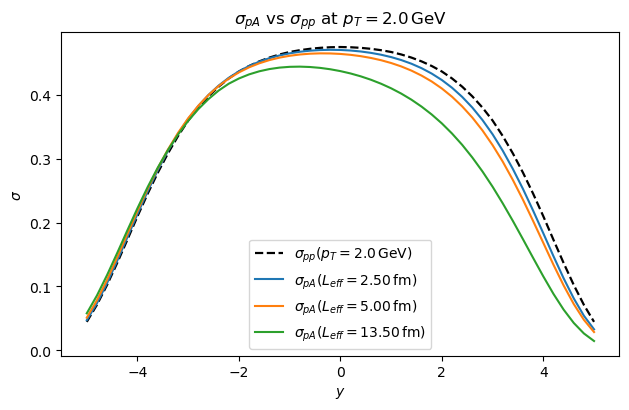

In [13]:
# =========================
# 2) RAW $\sigma_{pA}$ vs $\sigma_{pp}$ at several $L_{eff}$
#    Plotted against Rapidity ($y$)
# =========================
y_line = np.linspace(-5, 5, 51) # Define the rapidity range for the plot
pT_fix = 2.0                        # Fix a pT value (e.g., 5.0 GeV)
Lmb_5 = 5.0 # Assuming this is defined elsewhere, included for completeness
L_list = [2.5, Lmb_5, 13.5]

fig, ax = plt.subplots(figsize=(7.2,4.2))

# Calculate $\sigma_{pp}$ values against $y$
pp_vals = [TAB_chi_5(np.array([y]), pT_fix) for y in y_line]  # CPU table, assuming TAB_chi_5 takes (y, pT)
ax.plot(y_line, pp_vals, "k--", lw=1.6, label=fr"$\sigma_{{pp}}(p_T={pT_fix:.1f}\,\mathrm{{GeV}})$")

# Calculate $\sigma_{pA}$ values against $y$ for different $L_{eff}$
for L in L_list:
    vals = []
    for y in y_line:
        # Note: The xA_xB function signature is (P_charmonia, roots5, y_fix, pt, L, L)
        # We replace y_fix with the looping variable y and pt with the fixed pT_fix
        xA, _, mT, yM = xA_xB(P_charmonia, roots5, y, pT_fix, L, L)
        
        # Note: The sigma_pA function signature is (..., y_fix, pt, ...)
        sig = QF.sigma_pA(P_charmonia, roots5, replace(QP5, LA_fm=L), y, pT_fix,
                          TAB_chi_5, xA, yM, Ny=None, Nphi=16, use_torch=False)
        vals.append(sig)
        
    ax.plot(y_line, vals, label=fr"$\sigma_{{pA}}(L_{{eff}}={L:.2f}\,\mathrm{{fm}})$")

# Update axes labels and title
ax.set(xlabel=r"$y$", ylabel=r"$\sigma$",
       title=fr"$\sigma_{{pA}}$ vs $\sigma_{{pp}}$ at $p_T={pT_fix:.1f}\,\mathrm{{GeV}}$")
ax.legend()
plt.show()

In [14]:
# # =========================
# # 2) $R_{pA}$ vs $p_T$ at several $L_{eff}$
# # =========================
# pT_line = np.linspace(0.5, 10.0, 141) # Define the pT range for the plot
# y_fix   = -5                       # Fix a rapidity value (e.g., y=0.0)
# L_list  = [2.5, 3.0, 4.0, 6.0, 10.0,13.5] # List of effective lengths

# fig, ax = plt.subplots(figsize=(7.2,4.2))

# # Calculate $\sigma_{pp}$ values against $p_T$
# # Assuming TAB_chi_5 takes (y, pT)
# pp_vals = [TAB_chi_5(np.array([y_fix]), pt) for pt in pT_line]  # CPU $\sigma_{pp}$ table

# # Plot $\sigma_{pp}/\sigma_{pp}$ (i.e., the line at 1)
# ax.plot(pT_line, [1.0] * len(pT_line), "k--", lw=1.6)

# # Calculate $\sigma_{pA}$ values against $p_T$ for different $L_{eff}$
# for L in L_list:
#     vals = []
#     for pt in pT_line:
#         # Note: The xA_xB function signature is (P_charmonia, roots5, y_fix, pt, L, L)
#         # We use the fixed y_fix and the looping variable pt
#         xA, _, mT, yM = xA_xB(P_charmonia, roots5, y_fix, pt, L, L)
        
#         # Note: The sigma_pA function signature is (..., y_fix, pt, ...)
#         sig = QF.sigma_pA(P_charmonia, roots5, replace(QP5, LA_fm=L), y_fix, pt,
#                           TAB_chi_5, xA, yM, Ny=None, Nphi=64, use_torch=True)
#         vals.append(sig)
    
#     # Calculate the nuclear modification factor: $\sigma_{pA} / \sigma_{pp}$
#     res = [x/y for x,y in zip(vals,pp_vals)]
#     ax.plot(pT_line, res, label=fr"$L_{{eff}}={L:.2f}\,\mathrm{{fm}}$")

# # Update axes labels and title
# ax.set(xlabel=r"$p_T$ [GeV]", ylabel=r"$R_{pA}$",
#        title=fr"$R_{{pA}}$ vs $p_T$ at $y={y_fix:.1f}$")
# ax.legend()
# plt.show()

In [15]:
# # =========================
# # 2) $R_{pA}$ vs $p_T$ at several $L_{eff}$
# # =========================
# pT_line = np.linspace(0.5, 20.0, 141) # Define the pT range for the plot
# y_fix   = 5.0                       # Fix a rapidity value (e.g., y=0.0)
# L_list  = [2.5, 3.0, 4.0, 6.0, 10.0,13.5] # List of effective lengths

# fig, ax = plt.subplots(figsize=(7.2,4.2))

# # Calculate $\sigma_{pp}$ values against $p_T$
# # Assuming TAB_chi_5 takes (y, pT)
# pp_vals = [TAB_chi_5(np.array([y_fix]), pt) for pt in pT_line]  # CPU $\sigma_{pp}$ table

# # Plot $\sigma_{pp}/\sigma_{pp}$ (i.e., the line at 1)
# ax.plot(pT_line, [1.0] * len(pT_line), "k--", lw=1.6)

# # Calculate $\sigma_{pA}$ values against $p_T$ for different $L_{eff}$
# for L in L_list:
#     vals = []
#     for pt in pT_line:
#         # Note: The xA_xB function signature is (P_charmonia, roots5, y_fix, pt, L, L)
#         # We use the fixed y_fix and the looping variable pt
#         xA, _, mT, yM = xA_xB(P_charmonia, roots5, y_fix, pt, L, L)
        
#         # Note: The sigma_pA function signature is (..., y_fix, pt, ...)
#         sig = QF.sigma_pA(P_charmonia, roots5, replace(QP5, LA_fm=L), y_fix, pt,
#                           TAB_chi_5, xA, yM, Ny=None, Nphi=64, use_torch=True)
#         vals.append(sig)
    
#     # Calculate the nuclear modification factor: $\sigma_{pA} / \sigma_{pp}$
#     res = [x/y for x,y in zip(vals,pp_vals)]
#     ax.plot(pT_line, res, label=fr"$L_{{eff}}={L:.2f}\,\mathrm{{fm}}$")

# # Update axes labels and title
# ax.set(xlabel=r"$p_T$ [GeV]", ylabel=r"$R_{pA}$",
#        title=fr"$R_{{pA}}$ vs $p_T$ at $y={y_fix:.1f}$")
# ax.legend()
# plt.show()

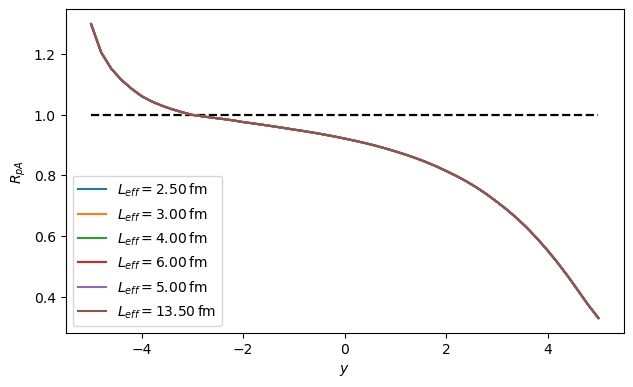

In [16]:
# =========================
# 2) RAW $\sigma_{pA}$ vs $\sigma_{pp}$ at several $L_{eff}$
#    Plotted against Rapidity ($y$)
# =========================
y_line = np.linspace(-5, 5, 51) # Define the rapidity range for the plot
pT_fix = 2.0                        # Fix a pT value (e.g., 5.0 GeV)
Lmb_5 = 5.0 # Assuming this is defined elsewhere, included for completeness
L_list = [2.5, 3.0, 4.0, 6.0, Lmb_5, 13.5]

fig, ax = plt.subplots(figsize=(7.2,4.2))

# Calculate $\sigma_{pp}$ values against $y$
pp_vals = [TAB_chi_5(np.array([y]), pT_fix) for y in y_line]  # CPU table, assuming TAB_chi_5 takes (y, pT)
ax.plot(y_line, [x/x for x in pp_vals], "k--", lw=1.6)

# Calculate $\sigma_{pA}$ values against $y$ for different $L_{eff}$
for L in L_list:
    # vals = []
    # print("-" * 50)
    # print(f"For L_eff ={L}:")
    # print("-" * 50)
    for y in y_line:
        # Note: The xA_xB function signature is (P_charmonia, roots5, y_fix, pt, L, L)
        # We replace y_fix with the looping variable y and pt with the fixed pT_fix
        xA, _, mT, yM = xA_xB(P_charmonia, roots5, y, pT_fix, L, L)
        
        # Note: The sigma_pA function signature is (..., y_fix, pt, ...)
        sig = QF.sigma_pA(P_charmonia, roots5, replace(QP5, LA_fm=L), y, pT_fix,
                          TAB_chi_5, xA, yM, Ny=None, Nphi=16, use_torch=True)
        vals.append(sig)
        
        pp_val = TAB_chi_5(y, pT_fix)
        # print(f"Result at {y}: ", sig/pp_val)
    
    res = [x/y for x,y in zip(vals,pp_vals)]
    
    ax.plot(y_line, res, label=fr"$L_{{eff}}={L:.2f}\,\mathrm{{fm}}$")

# Update axes labels and title
ax.set(xlabel=r"$y$", ylabel=r"$R_{pA}$")
ax.legend()
plt.show()

In [17]:
# Small helper to compute xA/xB
def xA_xB(P, roots, y, pT, LA, LB):
    mT = P.mT(pT)
    xA = min(QF.xA0_from_L(LA), (mT/roots)*np.exp(-y))
    xB = min(QF.xA0_from_L(LB), (mT/roots)*np.exp(+y))
    return xA, xB, mT, P.y_max(roots, mT)

In [18]:
# =========================
# 3) RAW R_pA and R_AA at a point
# =========================
y0, pT0 = 0, 6.0
R_pA_raw = QF.nuclear_modification(P_charmonia, roots5, QP5, y0, pT0, TAB_chi_5, kind="pA", use_torch=True)
R_AA_raw = QF.nuclear_modification(P_bottomonia, roots5, replace(QP5, LA_fm=Lmb_5, LB_fm=Lmb_5),
                                   y0, pT0, TAB_ups_5, kind="AA", use_torch=True)
print(f"RAW R_pA(J/psi) at y={y0}, pT={pT0}: {R_pA_raw:.3f}")
print(f"RAW R_AA(Upsilon) at y={y0}, pT={pT0}: {R_AA_raw:.3f}")

RAW R_pA(J/psi) at y=0, pT=6.0: 1.197
RAW R_AA(Upsilon) at y=0, pT=6.0: 6.764


In [19]:
import math
y_test  = np.array([-5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.5, 2.5, 5.0])
pT_test = 2.0
L_periph = 2.44
qpL = replace(QP5, LA_fm=L_periph)

def ycap_and_delta(qp, P, roots, y, pT):
    mT  = P.mT(pT)
    yM  = QF.y_max(roots, mT)
    dym = QF.dymax(-y, yM)   # A-leg uses -y
    return yM, dym

print("[check] y_max and δy_max(-y) at pT=%.2f GeV, L=%.2f fm" % (pT_test, L_periph))
for yy in y_test:
    yM, dym = ycap_and_delta(qpL, P_charmonia, roots5, yy, pT_test)
    print("  y=%+.1f  y_max=%.3f  δy_max(-y)=%.5f  (cap= min(ln2, y_max+ y) with y→-y)" % (yy, yM, dym))

# Cronin ΔpT sanity at tiny L
def dpt_side_tinyL(qp, P, roots, y, pT, L):
    xA = min(QF.xA0_from_L(L), (P.mT(pT)/roots)*math.exp(-y))
    # reusing the same math as in _dpt_from_xL_t (rough check without torch)
    lA2 = QF.qhat_of_x(qp, xA) * L
    lp2 = QF.qhat_of_x(qp, min(xA, QF.xA0_from_L(qp.lp_fm))) * qp.lp_fm
    base = max(lA2 - lp2, 0.0)
    taper = max((L - qp.lp_fm)/(L + 1e-9), 0.0)
    return math.sqrt(base) * taper

for L in [1.5, 2.0, 2.44, 3.0, 5, 10, 15]:
    print(f"[check] ΔpT_taper(L={L:.2f} fm) ≈ {dpt_side_tinyL(qpL, P_charmonia, roots5, -3.0, pT_test, L):.5f} GeV")

[check] y_max and δy_max(-y) at pT=2.00 GeV, L=2.44 fm
  y=-5.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=-4.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=-3.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=-2.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=-1.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=+0.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=+1.5  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=+2.5  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
  y=+5.0  y_max=7.144  δy_max(-y)=0.69315  (cap= min(ln2, y_max+ y) with y→-y)
[check] ΔpT_taper(L=1.50 fm) ≈ 0.00000 GeV
[check] ΔpT_taper(L=2.00 fm) ≈ 0.04518 GeV
[check] ΔpT_taper(L=2.44 fm) ≈ 0.09545 GeV
[check] ΔpT_taper(L=3.00 fm) ≈ 0.15650 GeV
[check] ΔpT_taper(L=5.00 fm) ≈ 0.33467 GeV
[check] ΔpT_taper(L

In [20]:
# --- RAW RpA(y) at fixed pT; 5.02 TeV, J/ψ and Υ ---
import matplotlib.pyplot as plt
from dataclasses import replace
import numpy as np
import quenching_fast as QF

# Grids to see the backward-y behavior cleanly
y_grid = np.linspace(-5.0, +5.0, 60)
pT_list = [1.0, 2.0, 6.0, 10.0, 15.0]  # low, mid, high pT checks

# L_eff from your Glauber:
c = float(Leff_5['80-100%'])
L_minbias = 10.41
qp_periph  = replace(QP5, LA_fm=L_periph)
qp_minbias = replace(QP5, LA_fm=L_minbias)

# def plot_raw_species(P, TAB, label):
#     fig, ax = plt.subplots(1, len(pT_list), figsize=(12, 3.6), sharey=True)
#     for k, pT_fix in enumerate(pT_list):
#         RpA_per = QF.rpa_raw_vs_y(P, roots5, qp_periph,  TAB if TAB is not None else P, y_grid, pT_fix, kind="pA")
#         RpA_min = QF.rpa_raw_vs_y(P, roots5, qp_minbias, TAB if TAB is not None else P, y_grid, pT_fix, kind="pA")
#         ax[k].plot(y_grid, RpA_per,  label=f"80–100%  L={L_periph:.2f} fm")
#         ax[k].plot(y_grid, RpA_min,  label=f"0–100%   L={L_minbias:.2f} fm", ls="--")
#         ax[k].axhline(1.0, ls=":", c="k", lw=0.9)
#         ax[k].set(title=rf"{label}, $p_T={pT_fix:.1f}$ GeV", xlabel="y")
#         ax[k].grid(alpha=0.15)
#     ax[0].set(ylabel=r"$R_{pA}(y)$")
#     handles, labs = ax[-1].get_legend_handles_labels()
#     fig.legend(handles, labs, ncol=2, frameon=False, loc="lower center")
#     fig.suptitle(rf"$R_{{pA}}(y)$, {label}, $\sqrt{{s_{{NN}}}}=5.02$ TeV")
#     plt.tight_layout(rect=(0,0.08,1,0.97))
#     plt.show()

# plot_raw_species(P_charmonia,  TAB_chi_5, r"J/$\psi$")

In [ ]:
# --- 5) BINNED curves vs y and vs pT at multiple centralities
cent_bins = [(80,100)]
Leff_5  = gl5.leff_bins_pA(cent_bins, method="optical")  # dict: "0-20%"→L_eff

# choose binning / weighting (fast & stable):
Y_EDGES = np.arange(-5.0, 5.0+0.25, 0.25)      # dy binning
PT_EDGES= np.arange(0.0,  15.0+1.25, 2.5)     # pT binning
y_range_for_pt = (-2.5, 2.5)                   # y window for RpA(pT)
pt_range_for_y = (0.0, 5.0)                    # pT window for RpA(y)

def binned_curve_vs_y(P, roots, QP_base, TAB, y_edges, pt_range, Leff_5,
                      weight="pp", weight_y0=0.0, Ny=18, Np=36):
    import matplotlib.pyplot as plt
    bins = sorted(Leff_5.items(), key=lambda kv: int(kv[0].split('-')[0]))
    colors = plt.get_cmap("tab10")(np.linspace(0,1,len(bins)))
    fig, ax = plt.subplots(figsize=(7.2,4.0))
    mids = 0.5*(y_edges[:-1]+y_edges[1:])
    for (lab,L), c in zip(bins, colors):
        qpL = replace(QP_base, LA_fm=float(L))
        vals=[]
        for yl, yr in zip(y_edges[:-1], y_edges[1:]):
            Rbar = QF.nuclear_modification_binned(
                P, roots, qpL, (yl,yr), pt_range, TAB, kind="pA",
                Ny_bin=Ny, Npt_bin=Np,
                weight_kind=("pp" if weight=="pp" else "pA"),
                weight_ref_y=(weight_y0 if weight_y0 is not None else None),
                use_torch=True
            )
            vals.append(Rbar)
        ax.step(mids, np.array(vals), where="mid", color=c, lw=1.8, label=f"{lab} (L={float(L):.2f} fm)")
    ax.axhline(1, ls=":", c="k"); ax.set(xlabel="y", ylabel=r"$\overline{R}_{pA}$")
    ax.legend(ncol=2, frameon=False, fontsize=9); plt.tight_layout(); plt.show()

In [ ]:
# J/ψ at 5.02 TeV, pA-weights evaluated at y=0 (your preferred fast mode: set weight="pp" for fastest)
binned_curve_vs_y(P_charmonia, roots5, QP5, TAB_chi_5, Y_EDGES, pt_range_for_y, Leff_5,
                  weight="pA", weight_y0=0.0, Ny=64, Np=64)

# # Υ at 5.02 TeV
# binned_curve_vs_y(P_bottomonia, roots5, QP5, TAB_ups_5, Y_EDGES, pt_range_for_y, Leff_5,
#                   weight="pA", weight_y0=0.0, Ny=18, Np=36)

# # J/ψ at 5.02 TeV, pA-weights evaluated at y=0 (your preferred fast mode: set weight="pp" for fastest)
# binned_curve_vs_y(P_charmonia, roots5, QP5, TAB_chi_5, Y_EDGES, pt_range_for_y, Leff_5,
#                   weight="pp", weight_y0=0.0, Ny=18, Np=36)

In [21]:
Y_THREE    = [(-4.46,-2.96), (-1.37,0.43), (2.03,3.53)] 

In [22]:
# # --- RAW RpA(L) at a few y values; 5.02 TeV, J/ψ ---
# import numpy as np, matplotlib.pyplot as plt

# y_probe  = [-5.0 -4.0, -3.0, -2.0, 0.0, +1.0, +3, +5]
# pT_fix   = 5.0
# L_scan   = np.linspace(1.5, 15.0, 22)   # from lp to above min-bias

# fig, ax = plt.subplots(figsize=(6.0,3.8))
# for yy in y_probe:
#     RvL = QF.rpa_raw_vs_L(P_charmonia, roots5, QP5, TAB_chi_5 if TAB_chi_5 is not None else P_charmonia,
#                           L_scan, y=yy, pT=pT_fix, kind="pA")
#     ax.plot(L_scan, RvL, label=f"y={yy:+.1f}")
# ax.axhline(1.0, ls=":", c="k", lw=0.9)
# ax.set(xlabel=r"$L_{\rm eff}$ [fm]", ylabel=r"$R_{pA}$",
#        title=rf"$R_{{pA}}(L)$, J/$\psi$, $p_T={pT_fix:.1f}$ GeV, $\sqrt{{s}}=5.02$ TeV")
# ax.legend(ncol=3, frameon=False, fontsize=9)
# ax.grid(alpha=0.15); plt.tight_layout(); plt.show()


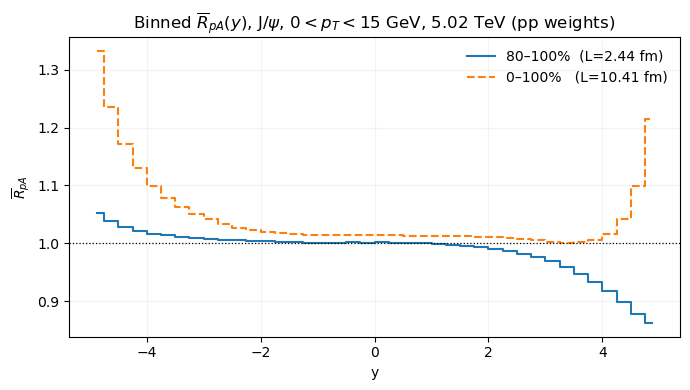

In [23]:
# --- Binned ⟨R⟩(y) using your nuclear_modification_binned (pp weights) ---
def binned_curve_vs_y_inline(P, roots, qp, TAB, y_edges, pt_range, kind="pA", weight="pA"):
    mids, vals = [], []
    for y0, y1 in zip(y_edges[:-1], y_edges[1:]):
        Rbar = QF.nuclear_modification_binned(
            P, roots, qp, (float(y0), float(y1)), (float(pt_range[0]), float(pt_range[1])),
            TAB if TAB is not None else P, kind=kind, weight_kind=weight,
            weight_ref_y=0.0,  # robust default; set to None to use local y
            Ny_bin=18, Npt_bin=36, use_torch=True
        )
        mids.append(0.5*(y0+y1)); vals.append(Rbar)
    return np.array(mids), np.array(vals)

fig, ax = plt.subplots(figsize=(7,4))
# 80–100%
y_mid, R_per = binned_curve_vs_y_inline(P_charmonia, roots5, qp_periph,  TAB_chi_5, Y_EDGES, (0.0, 15.0), "pA", "pA")
# 0–100%
y_mid, R_min = binned_curve_vs_y_inline(P_charmonia, roots5, qp_minbias, TAB_chi_5, Y_EDGES, (0.0, 15.0), "pA", "pA")
ax.step(y_mid, R_per, where="mid", label=f"80–100%  (L={L_periph:.2f} fm)")
ax.step(y_mid, R_min, where="mid", label=f"0–100%   (L={L_minbias:.2f} fm)", ls="--")
ax.axhline(1.0, ls=":", c="k", lw=0.9)
ax.set(xlabel="y", ylabel=r"$\overline{R}_{pA}$",
       title=r"Binned $\overline{R}_{pA}(y)$, J/$\psi$, $0<p_T<15$ GeV, 5.02 TeV (pp weights)")
ax.legend(frameon=False); ax.grid(alpha=0.15); plt.tight_layout(); plt.show()

In [24]:
# =========================
# 4) BINNED R_pA vs y and vs pT (flexible bins)
# =========================
def binned_curve_vs_y(P, roots, QP, TAB, y_edges, pt_range, kind="pA", weight_kind="pp"):
    mids, vals = [], []
    for yl, yr in zip(y_edges[:-1], y_edges[1:]):
        Rbar = QF.nuclear_modification_binned(P, roots, QP, (yl,yr), pt_range, TAB,
                                              kind=kind, Ny_bin=64, Npt_bin=48,
                                              use_torch=True, weight_kind=weight_kind)
        mids.append(0.5*(yl+yr)); vals.append(Rbar)
    return np.array(mids), np.array(vals)

def binned_curve_vs_pt(P, roots, QP, TAB, pt_edges, y_range, kind="pA", weight_kind="pp"):
    mids, vals = [], []
    for pl, pr in zip(pt_edges[:-1], pt_edges[1:]):
        Rbar = QF.nuclear_modification_binned(P, roots, QP, y_range, (pl,pr), TAB,
                                              kind=kind, Ny_bin=64, Npt_bin=48,
                                              use_torch=True, weight_kind=weight_kind)
        mids.append(0.5*(pl+pr)); vals.append(Rbar)
    return np.array(mids), np.array(vals)

In [25]:
##Example: RpA(y) in pT∈[0,5] GeV
# y_mid, R_vs_y = binned_curve_vs_y(P_charmonia, roots5, QP5, TAB_chi_5, Y_EDGES, (0.0, 5.0), kind="pA", weight_kind="pp")
# plt.figure(figsize=(6,4))
# plt.step(y_mid, R_vs_y, where="mid")
# plt.axhline(1.0, ls="--", c="k", lw=1)
# plt.xlabel("y"); plt.ylabel(r"$\overline{R}_{pA}$"); plt.title(r"$\overline{R}_{pA}(y)$, $0<p_T<5$ GeV")
# plt.show()

# y_mid, R_vs_y = binned_curve_vs_y(P_charmonia, roots5, QP5, TAB_chi_5, Y_EDGES, (0.0, 5.0), kind="pA", weight_kind="pA")
# plt.figure(figsize=(6,4))
# plt.step(y_mid, R_vs_y, where="mid")
# plt.axhline(1.0, ls="--", c="k", lw=1)
# plt.xlabel("y"); plt.ylabel(r"$\overline{R}_{pA}$"); plt.title(r"$\overline{R}_{pA}(y)$, $0<p_T<5$ GeV")
# plt.show()


# # Example: RpA(pT) in y∈[2.0,3.5]
# pt_mid, R_vs_pt = binned_curve_vs_pt(P_charmonia, roots5, QP5, TAB_chi_5, PT_EDGES, (2.0,3.5), kind="pA", weight_kind="pp")
# plt.figure(figsize=(6,4))
# plt.step(pt_mid, R_vs_pt, where="mid")
# plt.axhline(1.0, ls="--", c="k", lw=1)
# plt.xlabel(r"$p_T$ [GeV]"); plt.ylabel(r"$\overline{R}_{pA}$"); plt.title(r"$\overline{R}_{pA}(p_T)$, $2.0<y<3.5$")
# plt.show()

In [26]:
def _sort_bins_for_legend(Leff_5):
    """Return [(label, L)], sorted by centrality (0-10,10-20,...) if labels are like '0-10%'."""
    def key_of(lbl):
        # accept '0-10%' or '0-10' or (0,10) or "0,10"
        s = str(lbl).replace('%','').replace(' ','').replace(',','-')
        a, b = s.split('-')[:2]
        return (int(a), int(b))
    items = list(Leff_5.items())
    items.sort(key=lambda kv: key_of(kv[0]))
    return items

def plot_RpA_vs_y_bins(
    P, roots, QP_base, TAB, y_edges, pt_range, Leff_5,
    weight="pp", title=None, cmap="tab10", lw=1.8, alpha=0.95
):
    bins = _sort_bins_for_legend(Leff_5)
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(bins)))

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for (cent_lbl, L), color in zip(bins, colors):
        QPL = replace(QP_base, LA_fm=float(L))
        y_mid, R = binned_curve_vs_y(P, roots, QPL, TAB, y_edges, pt_range, kind="pA", weight_kind="pA")
        ax.step(y_mid, R, where="mid", color=color, lw=lw, alpha=alpha,
                label=f"{cent_lbl}  (L={float(L):.2f} fm)")

    ax.axhline(1.0, ls=":", c="k", lw=1.0)
    if title is None:
        title = rf"$\overline{{R}}_{{pA}}(y)$,  {pt_range[0]:.1f} < $p_T$ < {pt_range[1]:.1f} GeV"
    ax.set(title=title, xlabel="y", ylabel=rf"$\overline{{R}}_{{pA}}$")
    ax.legend(ncol=2, frameon=False, fontsize=9)
    ax.margins(x=0.02)
    plt.tight_layout(); plt.show()

In [ ]:
## J/ψ at 5.02 TeV, pT∈[0,5] GeV, pp-weight
plot_RpA_vs_y_bins(P_charmonia, roots5, QP5, TAB_chi_5, Y_EDGES, (0.0, 15.0), Leff_5,
                   weight="pp", title=r"$\overline{R}_{pA}(y)$, J/$\psi$, 5.02 TeV")

# plot_RpA_vs_y_bins(P_charmonia, roots5, QP5, TAB_chi_5, Y_EDGES, (0.0, 15.0), Leff_5,
#                    weight="pA", title=r"$\overline{R}_{pA}(y)$, J/$\psi$, 5.02 TeV")
# # ϒ at 5.02 TeV
# plot_RpA_vs_y_bins(P_bottomonia, roots5, QP5, TAB_ups_5, Y_EDGES, (0.0, 5.0), Leff_5,
#                    weight="pp", title=r"$\overline{R}_{pA}(y)$, $\Upsilon$, 5.02 TeV")

In [ ]:
def plot_RpA_vs_pt_bins(
    P, roots, QP_base, TAB, pt_edges, y_range, Leff_5,
    weight="pA", title=None, cmap="tab10", lw=1.8, alpha=0.95
):
    bins = _sort_bins_for_legend(L)
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(bins)))

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for (cent_lbl, L), color in zip(bins, colors):
        QPL = replace(QP_base, LA_fm=float(L))
        pt_mid, R = binned_curve_vs_pt(P, roots, QPL, TAB, pt_edges, y_range, kind="pA", weight_kind=weight)
        ax.step(pt_mid, R, where="mid", color=color, lw=lw, alpha=alpha,
                label=f"{cent_lbl}  (L={float(L):.2f} fm)")

    ax.axhline(1.0, ls=":", c="k", lw=1.0)
    if title is None:
        title = rf"$\overline{{R}}_{{pA}}(p_T)$,  {y_range[0]:.1f} < y < {y_range[1]:.1f}"
    ax.set(title=title, xlabel=r"$p_T$ [GeV]", ylabel=rf"$\overline{{R}}_{{pA}}$")
    ax.legend(ncol=2, frameon=False, fontsize=9)
    ax.margins(x=0.02)
    plt.tight_layout(); plt.show()

In [ ]:
# # J/ψ at 5.02 TeV, y∈[2.0,3.5], pp or pA-weight
# plot_RpA_vs_pt_bins(P_charmonia, roots5, QP5, TAB_chi_5, PT_EDGES, (2.0, 3.5), Leff_5,
#                     weight="pp", title=r"$\overline{R}_{pA}(p_T)$, J/$\psi$, 5.02 TeV")

# plot_RpA_vs_pt_bins(P_charmonia, roots5, QP5, TAB_chi_5, PT_EDGES, (2.0, 3.5), Leff_5,
#                     weight="pA", title=r"$\overline{R}_{pA}(p_T)$, J/$\psi$, 5.02 TeV")

# # ϒ at 5.02 TeV
# plot_RpA_vs_pt_bins(P_bottomonia, roots5, QP5, TAB_ups_5, PT_EDGES, (2.0, 3.5), Leff_5,
#                     weight="pp", title=r"$\overline{R}_{pA}(p_T)$, $\Upsilon$, 5.02 TeV")

UnboundLocalError: cannot access local variable 'L' where it is not associated with a value

In [ ]:
# # J/ψ at 5.02 TeV, y∈[2.0,3.5], pp or pA-weight
# plot_RpA_vs_pt_bins(P_charmonia, roots5, QP5, TAB_chi_5, PT_EDGES, (-5.0, -2.5), Leff_5,
#                     weight="pp", title=r"$\overline{R}_{pA}(p_T)$, J/$\psi$, 5.02 TeV")

# plot_RpA_vs_pt_bins(P_charmonia, roots5, QP5, TAB_chi_5, PT_EDGES, (-5.0, -2.5), Leff_5,
#                     weight="pA", title=r"$\overline{R}_{pA}(p_T)$, J/$\psi$, 5.02 TeV")


In [ ]:
# # =========================
# # 5) RpA vs centrality (use Glauber to set L_eff per bin)
# # =========================
# cent_bins = [(0,20),(20,40),(40,60),(60,80),(80,100)]
# # cent_bins = [(0,10),(10,20),(20,30),(30,40),(40,50),(50,60),(60,70),(70,80),(80,90),(90,100)]
# Leff_5  = gl5.leff_bins_pA(cent_bins, method="optical")  # or "binomial"

# # Compute Rbar per bin for a chosen (y,pT) window
# y_rng  = (-5.0, -2.5)
# pt_rng = (0.0, 20.0)
# centers, R_cent = [], []
# for (c0,c1) in cent_bins:
#     L = Leff_5[f"{c0}-{c1}%"]
#     qpL = replace(QP5, LA_fm=L)  # set per-bin L_eff
#     Rbar = QF.nuclear_modification_binned(P_charmonia, roots5, qpL, y_rng, pt_rng,
#                                           TAB_chi_5, kind="pA",
#                                           Ny_bin=24, Npt_bin=48, use_torch=True, weight="pp")
#     centers.append(0.5*(c0+c1)); R_cent.append(Rbar)

# plt.figure(figsize=(6,4))
# plt.plot(centers, R_cent, "o-")
# plt.axhline(1.0, ls="--", c="k", lw=1)
# plt.xlabel("Centrality [%]"); plt.ylabel(r"$\overline{R}_{pA}$")
# plt.title(r"$\overline{R}_{pA}$ vs centrality (optical), full y,p_T$")
# plt.gca().invert_xaxis();  # optional: show central (0%) on left
# plt.show()

In [ ]:
# # =========================
# # 5) RpA vs centrality (use Glauber to set L_eff per bin)
# # =========================
# cent_bins = [(0,20),(20,40),(40,60),(60,80),(80,100)]
# # cent_bins = [(0,10),(10,20),(20,30),(30,40),(40,50),(50,60),(60,70),(70,80),(80,90),(90,100)]
# Leff_5  = gl5.leff_bins_pA(cent_bins, method="optical")  # or "binomial"

# # Compute Rbar per bin for a chosen (y,pT) window
# y_rng  = (-0.93, 1.5)
# pt_rng = (0.0, 20.0)
# centers, R_cent = [], []
# for (c0,c1) in cent_bins:
#     L = Leff_5[f"{c0}-{c1}%"]
#     qpL = replace(QP5, LA_fm=L)  # set per-bin L_eff
#     Rbar = QF.nuclear_modification_binned(P_charmonia, roots5, qpL, y_rng, pt_rng,
#                                           TAB_chi_5, kind="pA",
#                                           Ny_bin=24, Npt_bin=48, use_torch=True, weight="pp")
#     centers.append(0.5*(c0+c1)); R_cent.append(Rbar)

# plt.figure(figsize=(6,4))
# plt.plot(centers, R_cent, "o-")
# plt.axhline(1.0, ls="--", c="k", lw=1)
# plt.xlabel("Centrality [%]"); plt.ylabel(r"$\overline{R}_{pA}$")
# plt.title(r"$\overline{R}_{pA}$ vs centrality (optical), full y,p_T$")
# plt.gca().invert_xaxis();  # optional: show central (0%) on left
# plt.show()